# ClimateShield India

## Objective

The objective of this project is to develope an Explainable machine learning model that predicts climate-driven disease risk in Indian districts using rainfall, temperature, vegetation, geographical location, and historical disease data.

## Data Description

**Source:** Climate_data.csv

### Features

- week_of_outbreak : Week of disease occurrence
- state_ut : State/UT name
- district : District name
- Disease : Disease type
- Cases : Number of reported cases
- Deaths : Number of deaths
- day : Day
- mon : Month
- year : Year
- Latitude : Geographic latitude
- Longitude : Geographic longitude
- preci : Rainfall
- LAI : Leaf Area Index
- Temp : Temperature

### Target Variable

Disease Risk Level (derived from Cases)

## Import required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Loading & Preprocessing dataset

In [2]:
df = pd.read_csv("Climate_data.csv")

In [3]:
df.head()

,Unnamed: 0,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,NaN,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2.0,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,NaN,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,NaN,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000


## Removing unnecessary index columns and displaying the cleaned dataset.

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.head()

,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,NaN,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2.0,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,NaN,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,NaN,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000


## Dataset structure and overview.

In [6]:
df.shape

(8985, 14)

In [7]:
df.columns

Index(['week_of_outbreak', 'state_ut', 'district', 'Disease', 'Cases',
       'Deaths', 'day', 'mon', 'year', 'Latitude', 'Longitude', 'preci', 'LAI',
       'Temp'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8985 entries, 0 to 8984
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week_of_outbreak  8985 non-null   object 
 1   state_ut          8985 non-null   object 
 2   district          8985 non-null   object 
 3   Disease           8985 non-null   object 
 4   Cases             8985 non-null   object 
 5   Deaths            2554 non-null   float64
 6   day               8985 non-null   int64  
 7   mon               8985 non-null   int64  
 8   year              8985 non-null   int64  
 9   Latitude          8985 non-null   float64
 10  Longitude         8985 non-null   float64
 11  preci             8849 non-null   float64
 12  LAI               6790 non-null   float64
 13  Temp              8047 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 982.9+ KB


## Data cleaning and quality check.

In [9]:
df.isnull().sum()

week_of_outbreak       0
state_ut               0
district               0
Disease                0
Cases                  0
Deaths              6431
day                    0
mon                    0
year                   0
Latitude               0
Longitude              0
preci                136
LAI                 2195
Temp                 938
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

week_of_outbreak     0.000000
state_ut             0.000000
district             0.000000
Disease              0.000000
Cases                0.000000
Deaths              71.574847
day                  0.000000
mon                  0.000000
year                 0.000000
Latitude             0.000000
Longitude            0.000000
preci                1.513634
LAI                 24.429605
Temp                10.439622
dtype: float64

In [11]:
df["Deaths"] = df["Deaths"].fillna(0)

In [12]:
df.isnull().sum()

week_of_outbreak       0
state_ut               0
district               0
Disease                0
Cases                  0
Deaths                 0
day                    0
mon                    0
year                   0
Latitude               0
Longitude              0
preci                136
LAI                 2195
Temp                 938
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(35)

In [14]:
df = df.drop_duplicates()

In [15]:
df.describe()

,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
count,8950.000000,8950.00000,8950.000000,8950.000000,8950.000000,8950.000000,8814.000000,6764.000000,8015.000000
mean,0.451732,15.41162,6.985587,2014.664804,20.629714,80.109917,0.461434,10.914326,304.520119
std,2.966130,8.87889,2.688364,3.350605,5.874141,5.699885,0.626468,7.917479,6.986751
min,0.000000,1.00000,1.000000,2009.000000,8.079252,68.968002,0.000002,0.000000,259.680000
25%,0.000000,8.00000,5.000000,2012.000000,16.637138,75.919568,0.023539,5.000000,300.600000
50%,0.000000,15.00000,7.000000,2015.000000,21.347763,78.116914,0.225489,9.000000,303.460000
75%,0.000000,23.00000,9.000000,2017.000000,24.796436,84.514450,0.671773,14.000000,308.591000
max,147.000000,31.00000,12.000000,2022.000000,34.611024,95.945234,5.680000,62.000000,327.728000


## Exploratory Data Analysis (EDA)

This section analyzes the distribution of disease cases, climate variables, and geographical patterns using statistical and visual methods.

In [16]:
print("Rows & Columns :", df.shape)
print("\nColumn Names\n")
print(df.columns)

Rows & Columns : (8950, 14)

Column Names

Index(['week_of_outbreak', 'state_ut', 'district', 'Disease', 'Cases',
       'Deaths', 'day', 'mon', 'year', 'Latitude', 'Longitude', 'preci', 'LAI',
       'Temp'],
      dtype='object')


## Visualization of Disease case distribution

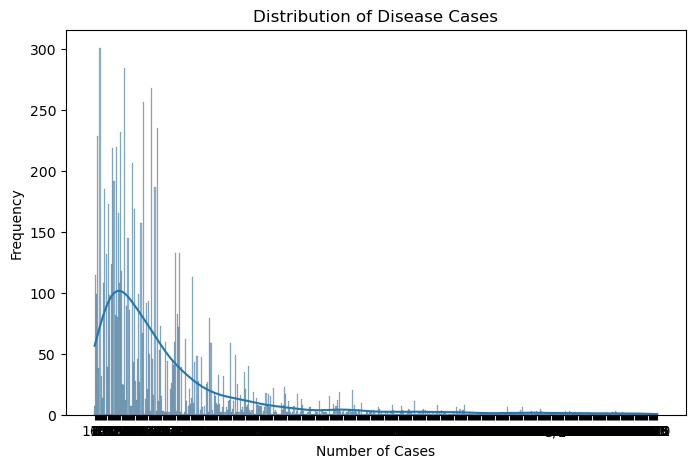

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Cases"], bins=30, kde=True)

plt.title("Distribution of Disease Cases")
plt.xlabel("Number of Cases")
plt.ylabel("Frequency")

plt.show()

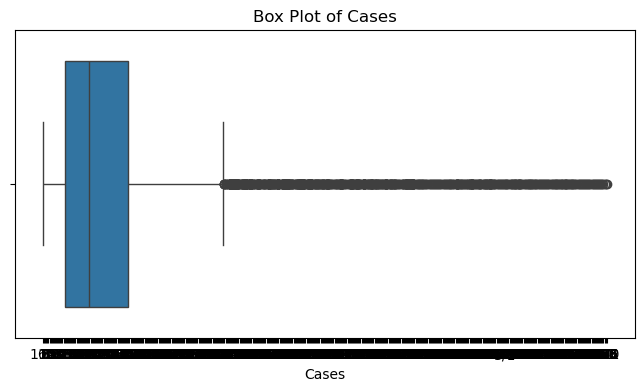

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Cases"])

plt.title("Box Plot of Cases")

plt.show()

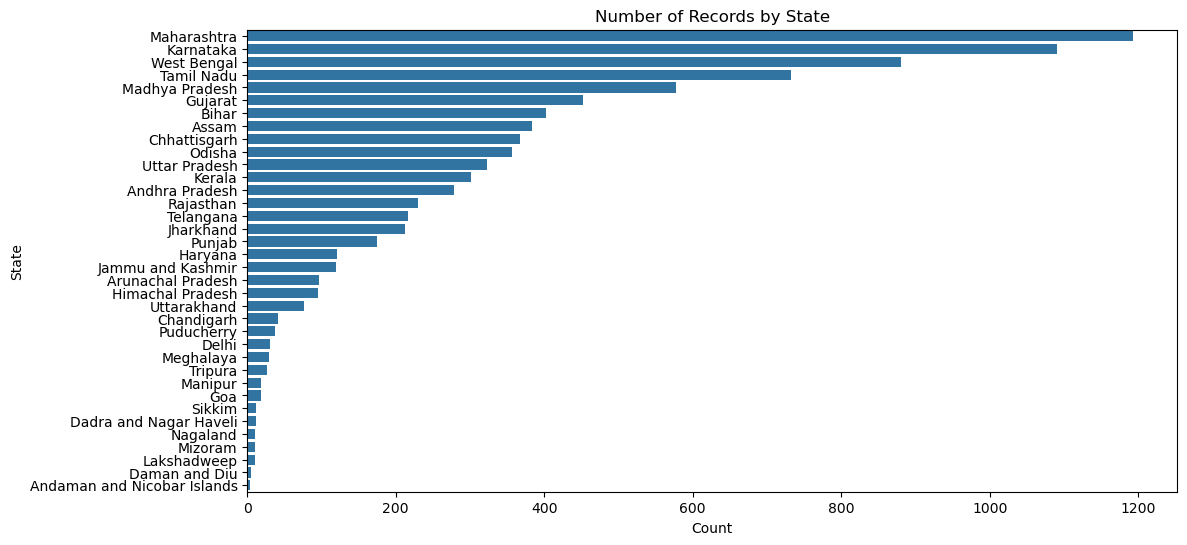

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              y="state_ut",
              order=df["state_ut"].value_counts().index)
plt.title("Number of Records by State")
plt.xlabel("Count")
plt.ylabel("State")
plt.show()

## Data type conversion and missing-value handling.

In [20]:
print(df["Cases"].dtype)

object


In [21]:
df["Cases"] = pd.to_numeric(df["Cases"], errors="coerce")

In [22]:
df["Deaths"] = pd.to_numeric(df["Deaths"], errors="coerce")

In [23]:
df["Cases"] = df["Cases"].fillna(0)
df["Deaths"] = df["Deaths"].fillna(0)

## Visualization

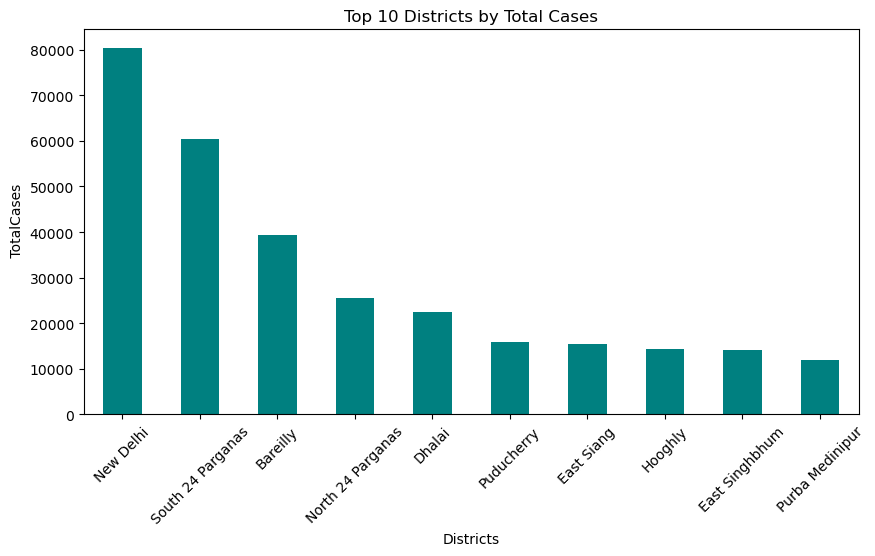

In [24]:
top_district = df.groupby("district")["Cases"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_district.plot(kind="bar", color="teal")

plt.title("Top 10 Districts by Total Cases")
plt.xlabel("Districts")
plt.ylabel(" TotalCases")

plt.xticks(rotation=45)

plt.show()

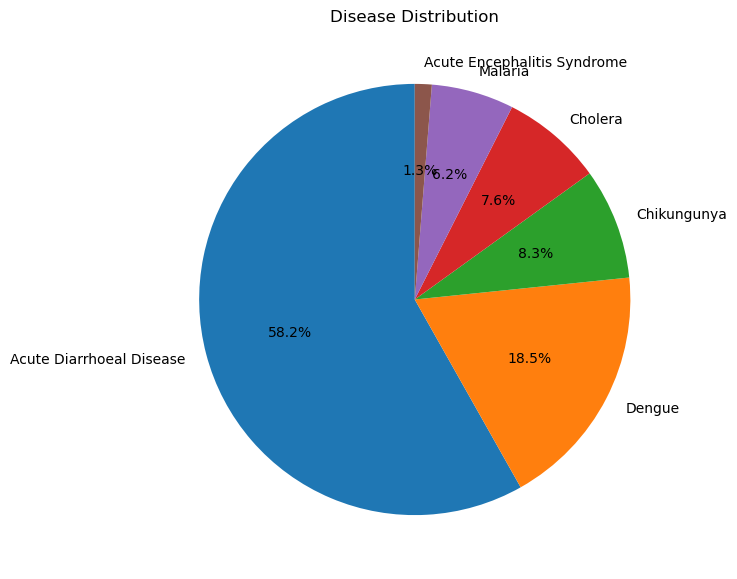

In [25]:
disease = df["Disease"].value_counts().head(6)

plt.figure(figsize=(7,7))

plt.pie(disease,
        labels=disease.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Disease Distribution")

plt.show()

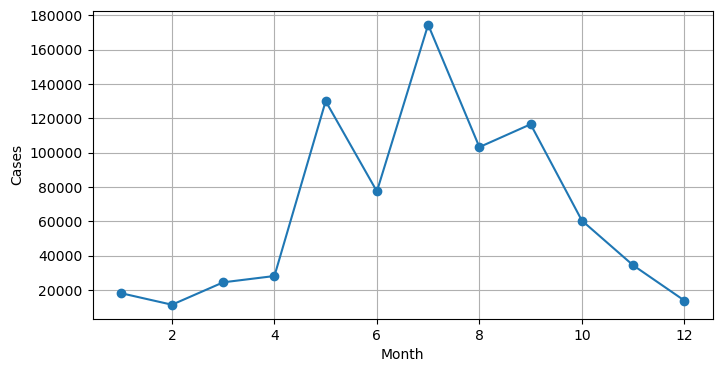

In [26]:
monthly = df.groupby("mon")["Cases"].sum()

plt.figure(figsize=(8,4))

plt.plot(monthly.index,
         monthly.values,
         marker="o")
plt.xlabel("Monthly Disease Cases")
plt.xlabel("Month")
plt.ylabel("Cases")

plt.grid(True)
plt.show()

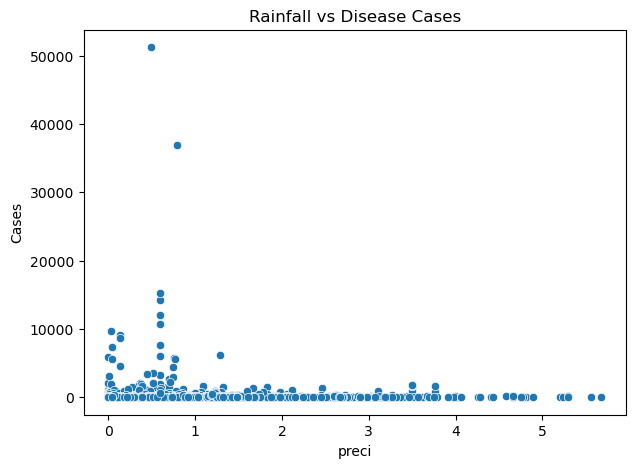

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="preci",
                y="Cases")
plt.title("Rainfall vs Disease Cases")

plt.show()

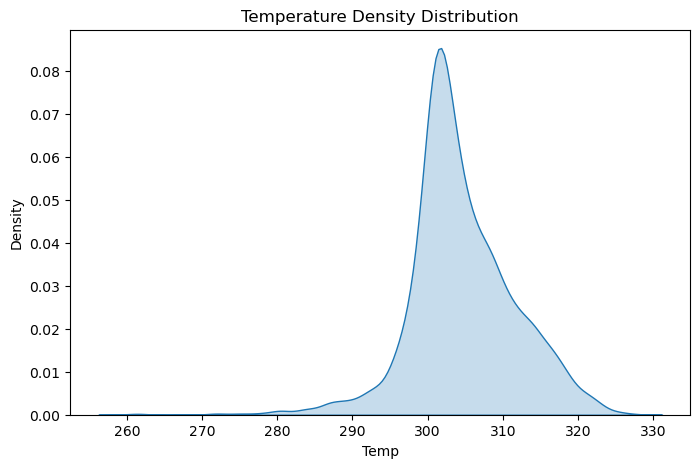

In [28]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["Temp"], fill=True)

plt.title("Temperature Density Distribution")

plt.show()

## Correlation Analysis

* Visualized correlations between numerical variables using heatmap
* Identified relationships between climate factors and disease cases.

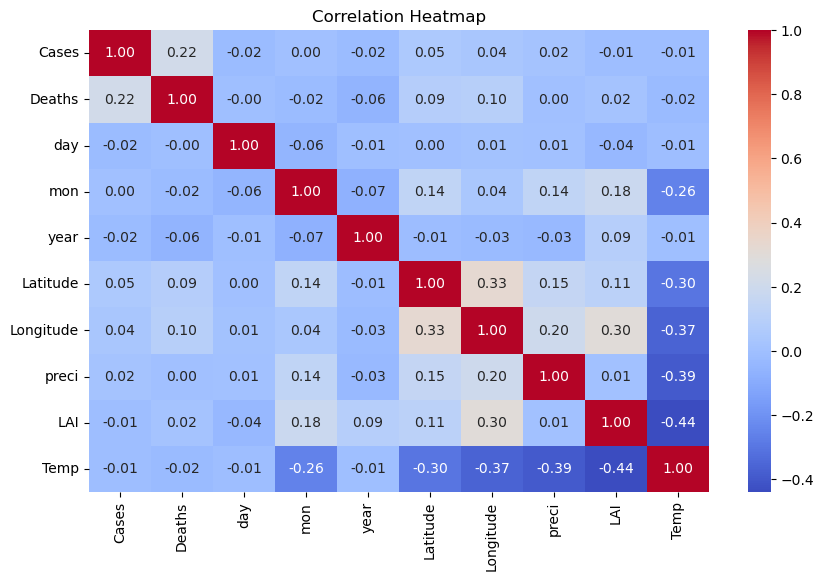

In [29]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Pairplot Analysis

* Visualized relationships and patterns among key climate and disease variables.
* Helped identity trends and potential feature correlations.

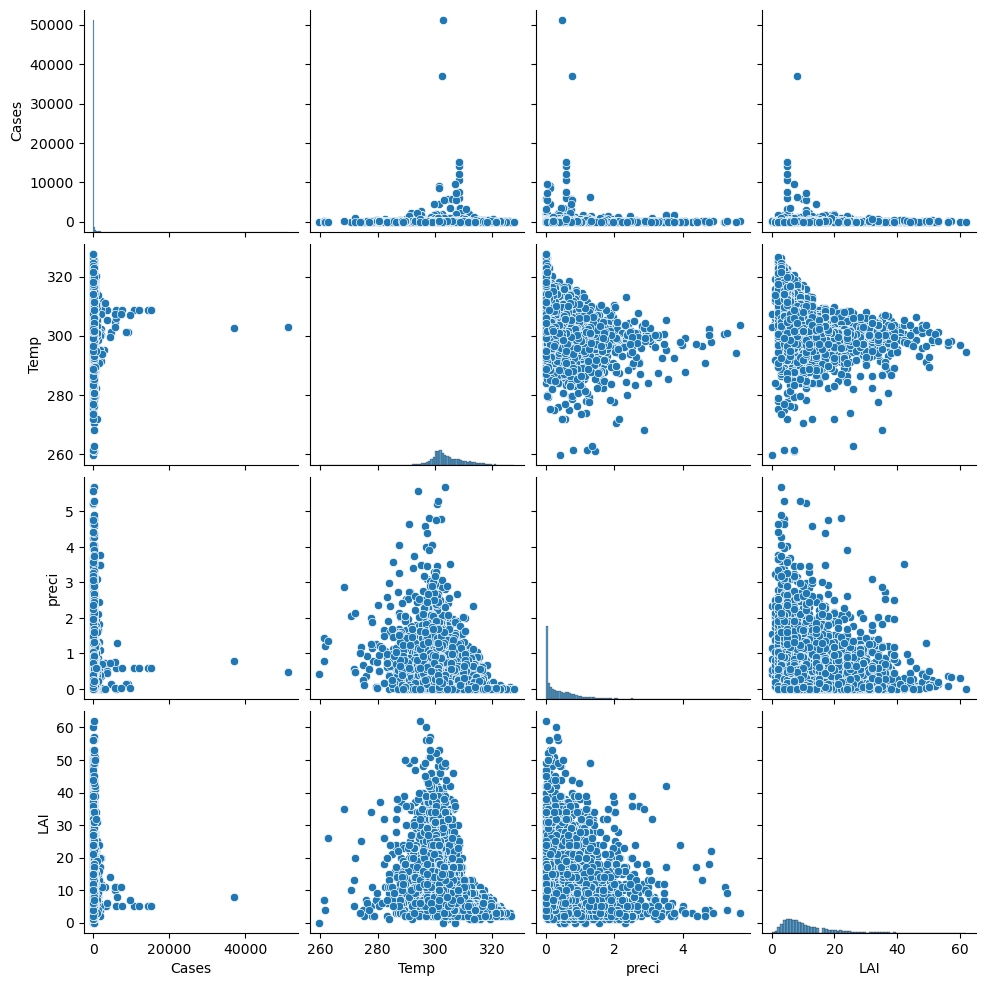

In [30]:
cols = ["Cases", "Temp", "preci", "LAI"]

sns.pairplot(df[cols])

plt.show()

## State-wise Temperature Analysis

* Compared the average temperature across different states.
* Highlighted regional temperature variations using a bar chart.

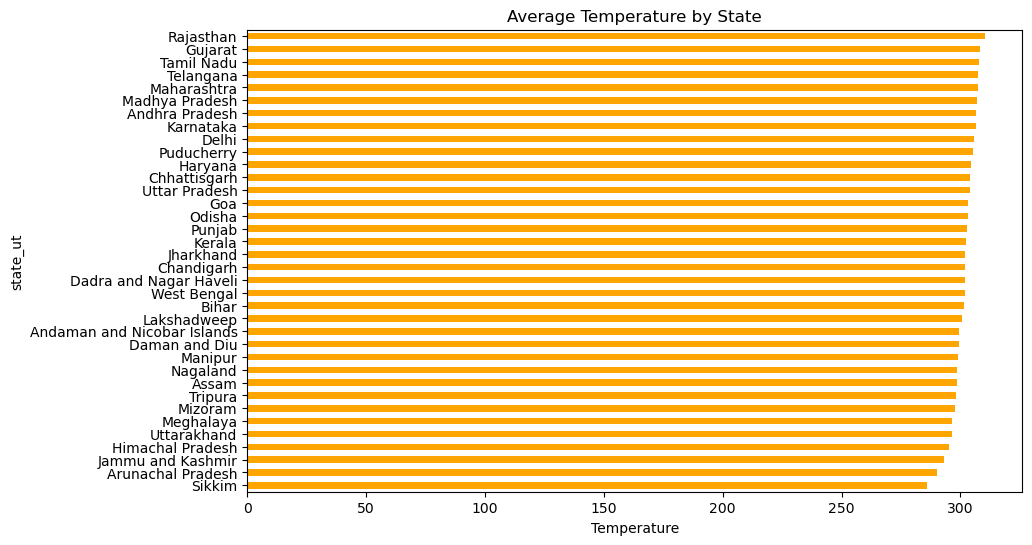

In [31]:
state_temp = df.groupby("state_ut")["Temp"].mean().sort_values()

plt.figure(figsize=(10,6))

state_temp.plot(kind="barh", color="orange")

plt.title("Average Temperature by State")

plt.xlabel("Temperature")

plt.show()

# Data Preprocessing

## Outlier Detection

* Detected extreme values in disese cases using a box plot.
* Helped identify anomalies in the dataset.

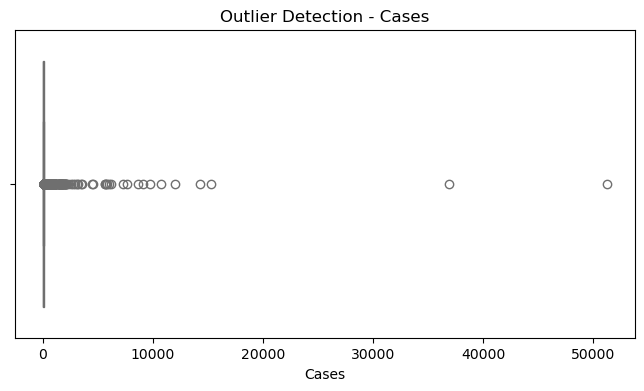

In [32]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Cases"], color="skyblue")

plt.title("Outlier Detection - Cases")

plt.show()

## IQR-Based Outlier Detection

* Calulated Q1, Qand IQR to determine the normal range of disease cases.
* Established lower and upper limits for identifying outliers.

In [33]:
Q1 = df["Cases"].quantile(0.25)

Q3 = df["Cases"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print("Q1 :", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

Q1 : 15.0
Q3: 53.0
IQR: 38.0
Lower Limit: -42.0
Upper Limit: 110.0


## Outlier Identification

* Identified records where disease cases fall ouotside the calculated IQR limits.
* Counted the total number of detected outliers.

In [34]:
outliers = df[(df["Cases"] < lower) | (df["Cases"] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 949


## Outlier Removal
* Removed extreme case values using the IQR limits
* Compared the dataset size before and after cleaning.

In [35]:
df_clean = df[(df["Cases"] >= lower) & (df["Cases"] <= upper)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (8950, 14)
After Removing Outliers: (8001, 14)


## Visualization - Disease case distribution after removing outliers to check cleaned data pattern.

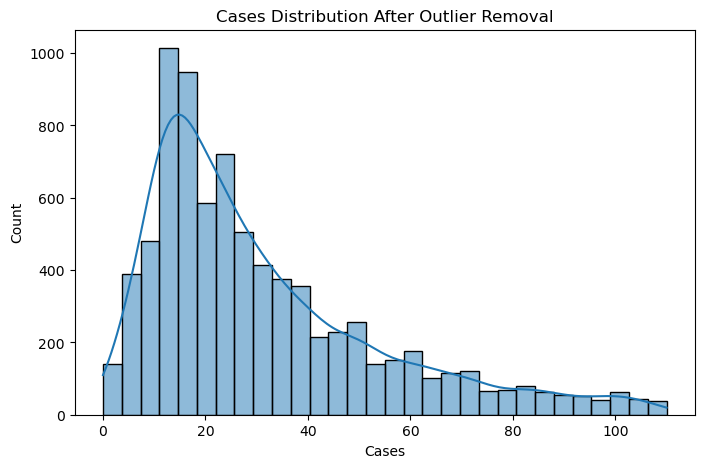

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Cases"], kde=True, bins=30)

plt.title("Cases Distribution After Outlier Removal")
plt.show()

## Skewness Analysis

* Measured the Skewness OR asymmetry of the disease-case distribution after outlier removal.
* Found the Cases distribution is positively (right) skewed.

In [37]:
sk = df_clean["Cases"].skew()

print("Skewness =", round(sk,2))

Skewness = 1.29


## Log Transformation

* Applied log transformation to the disease-case values to reduce skewness and make the distribution more suitable for ML modeling.

In [38]:
df_clean["Cases_Log"] = np.log1p(df_clean["Cases"])

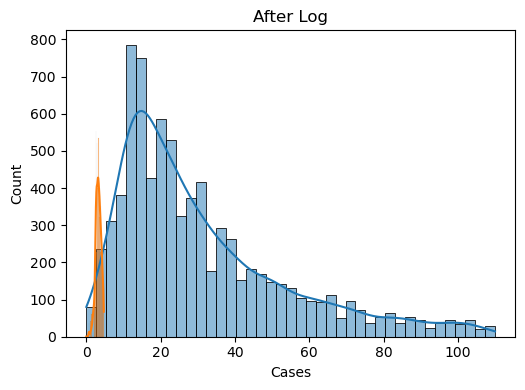

In [39]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_clean["Cases"], kde=True)
plt.title("Before Log")

plt.subplot(1,2,1)
sns.histplot(df_clean["Cases_Log"], kde=True)
plt.title("After Log")

plt.tight_layout()
plt.show()

## Feature Engineering (Target Variable Creation)
* The risk_level() function classifies disease cases into Low, Medium or High risk based o predefined thresholds.
* The resulting risk category is stored in a new Disease_Risk column, which is used as target variable for further analysis or machine learning.

In [40]:
def risk_level(cases):
    if cases <= 10:
        return "Low"
    elif cases <= 40:
        return "Medium"
    else:
        return "High"
        
df_clean["Disease_Risk"] = df_clean["Cases"].apply(risk_level)

In [41]:
df_clean[["Cases","Disease_Risk"]].head(10)

,Cases,Disease_Risk
1,7.0,Low
2,8.0,Low
3,7.0,Low
4,14.0,Medium
6,1.0,Low
7,1.0,Low
8,15.0,Medium
9,67.0,High
10,89.0,High
11,5.0,Low


In [42]:
df_clean["Cases"].describe()

count    8001.000000
mean       31.212348
std        23.043460
min         0.000000
25%        14.000000
50%        24.000000
75%        41.000000
max       110.000000
Name: Cases, dtype: float64

In [43]:
print(df_clean["Disease_Risk"].value_counts())

Disease_Risk
Medium    4921
High      2072
Low       1008
Name: count, dtype: int64


## Disease Risk Distribution Visualization
* Countplot is created to visualize the number of records in each Disease Risk category (Low, Medium and High).

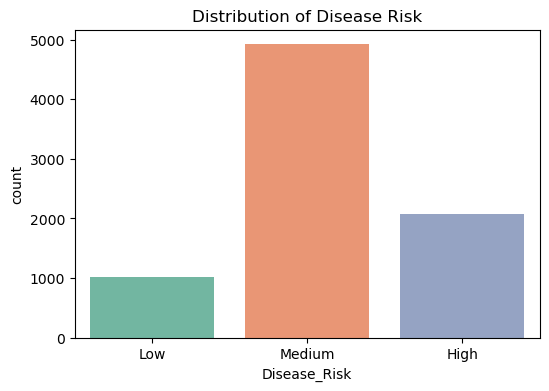

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean,
                x="Disease_Risk",
                order=["Low","Medium","High"],
                palette="Set2")
plt.title("Distribution of Disease Risk")

plt.show()

In [45]:
risk_counts = df_clean["Disease_Risk"].value_counts()

print(risk_counts)

print("\nPercentage Distribution:")
print((risk_counts / len(df_clean) * 100).round(2))

Disease_Risk
Medium    4921
High      2072
Low       1008
Name: count, dtype: int64

Percentage Distribution:
Disease_Risk
Medium    61.5
High      25.9
Low       12.6
Name: count, dtype: float64


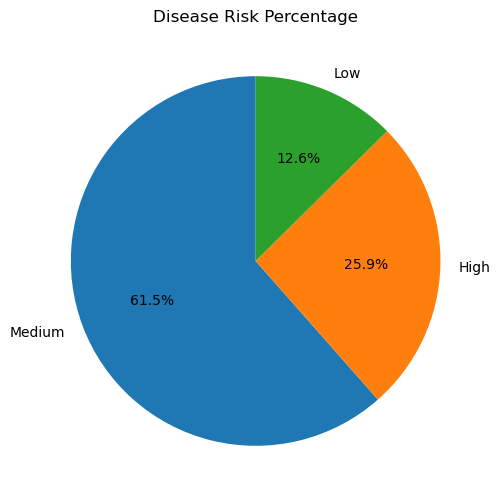

In [46]:
risk = df_clean["Disease_Risk"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(risk,
        labels=risk.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Disease Risk Percentage")
plt.show()

## Feature Encoding

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clean["Risk_Label"] = le.fit_transform(df_clean["Disease_Risk"])

In [48]:
risk_map = {
    "Low":0,
    "Medium":1,
    "High":2
}
df_clean["Risk_Label"] = df_clean["Disease_Risk"].map(risk_map)

In [49]:
df_clean[["Disease_Risk","Risk_Label"]].head()

,Disease_Risk,Risk_Label
1,Low,0
2,Low,0
3,Low,0
4,Medium,1
6,Low,0


In [50]:
print(risk_map)

{'Low': 0, 'Medium': 1, 'High': 2}


In [51]:
df_clean.dtypes

week_of_outbreak     object
state_ut             object
district             object
Disease              object
Cases               float64
Deaths              float64
day                   int64
mon                   int64
year                  int64
Latitude            float64
Longitude           float64
preci               float64
LAI                 float64
Temp                float64
Cases_Log           float64
Disease_Risk         object
Risk_Label            int64
dtype: object

In [52]:
X = df_clean[
    [
        "week_of_outbreak",
        "state_ut",
        "district",
        "Disease",
        "day",
        "mon",
        "year",
        "Latitude",
        "Longitude",
        "preci",
        "LAI",
        "Temp"
    ]
    
    
]

y = df_clean["Risk_Label"]

In [53]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8001, 12)
y shape: (8001,)


In [54]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "week_of_outbreak",
        "state_ut",
        "district",
        "Disease"
    ],
    drop_first=True

)

In [55]:
X_encoded.head()

,day,mon,year,Latitude,Longitude,preci,LAI,Temp,week_of_outbreak_11th week,week_of_outbreak_12th week,...,Disease_Dengue/Chikungunya,Disease_Diarrhea,Disease_Gastroenteritis,Disease_Malaria,Disease_Malaria (PV),Disease_Suspected Chikungunya,Disease_Suspected Cholera,Disease_Suspected Dengue,Disease_Suspected Dengue And Chikungunya,Disease_pyrexia of unknown origin
1,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000,False,False,...,False,False,False,True,False,False,False,False,False,False
2,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667,False,False,...,False,False,False,False,False,False,False,False,False,False
3,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000,False,False,...,False,False,False,False,False,False,False,False,False,False
6,24,1,2022,25.843539,80.918004,0.099030,NaN,290.180000,False,False,...,False,False,False,False,False,False,False,False,False,False


In [56]:
print("Before Encoding:", X.shape)
print("After Encoding:", X_encoded.shape)

Before Encoding: (8001, 12)
After Encoding: (8001, 872)


In [57]:
print("total missing values:", X_encoded.isna().sum().sum())

print("\nColumns having missing values:")
print(X_encoded.columns[X_encoded.isna().any()].tolist())

total missing values: 2961

Columns having missing values:
['preci', 'LAI', 'Temp']


In [58]:
numeric_features = [
    "day",
    "mon",
    "year",
    "Latitude",
    "Longitude",
    "preci",
    "LAI",
    "Temp"

]

for col in numeric_features:
    X_encoded[col] = X_encoded[col].fillna(X_encoded[col].median())

print("Remaining missing values:", X_encoded.isna().sum().sum())

Remaining missing values: 0


## Train-Test Split
* The dataset is divided into training (80%) and testing (20%) sets using train_test_split().
* Here stratify=y maintains the same class distribution in both sets.

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:",y_test.shape)

X_train: (6400, 872)
X_test: (1601, 872)
y_train: (6400,)
y_test: (1601,)


## Feature Scaling

* StandardScaler is used to standardize the numerical feature in the dataset so that they have a common scale.
* The scaler is fitted only on the training data and then applied to both training and test data, preventing data leakage.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Scaling completed successfully.")

Scaling completed successfully.


In [61]:
print("Training set class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Training set class distribution:
Risk_Label
0     806
1    3936
2    1658
Name: count, dtype: int64

Test set class distribution:
Risk_Label
0    202
1    985
2    414
Name: count, dtype: int64


In [62]:
print("Training set percentages:")
print((y_train.value_counts(normalize=True) * 100).sort_index().round(2))

print("\nTest set percentages:")
print((y_test.value_counts(normalize=True) * 100).sort_index().round(2))

Training set percentages:
Risk_Label
0    12.59
1    61.50
2    25.91
Name: proportion, dtype: float64

Test set percentages:
Risk_Label
0    12.62
1    61.52
2    25.86
Name: proportion, dtype: float64


In [63]:
print("Scaled training data statistics:")
print(X_train[numeric_features].describe().loc[["mean", "std"]])

Scaled training data statistics:
               day           mon          year      Latitude     Longitude  \
mean  9.769963e-17 -3.108624e-17  2.987610e-14  2.320366e-16 -9.720003e-16   
std   1.000078e+00  1.000078e+00  1.000078e+00  1.000078e+00  1.000078e+00   

             preci           LAI          Temp  
mean -6.772360e-17 -1.970646e-17 -1.550982e-15  
std   1.000078e+00  1.000078e+00  1.000078e+00  


In [64]:
print("Scaled test data statistics:")
print(X_test[numeric_features].describe().loc[["mean", "std"]])

Scaled test data statistics:
           day       mon      year  Latitude  Longitude     preci       LAI  \
mean -0.023502 -0.015068 -0.023236 -0.040806  -0.071406 -0.032072  0.026519   
std   1.003733  1.020283  0.995470  1.020218   0.976458  0.965377  1.080721   

          Temp  
mean  0.032116  
std   1.029953  


## Model Building

## 1. Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [67]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression training completed!")

Logistic Regression training completed!


In [68]:
y_pred_logistic = logistic_model.predict(X_test)

print("Prediction completed:")
print("First 10 prediction:", y_pred_logistic[:10])

Prediction completed:
First 10 prediction: [1 1 0 1 1 1 1 1 1 1]


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)


recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression Results")
print("****************************")
print("Acuuracy:", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall:", round(recall_logistic, 4))
print("F1 Score:", round(f1_logistic, 4))

Logistic Regression Results
****************************
Acuuracy: 0.6009
Precision: 0.5495
Recall: 0.6009
F1 Score: 0.5427


In [70]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.51      0.16      0.25       202
      Medium       0.64      0.88      0.74       985
        High       0.36      0.16      0.22       414

    accuracy                           0.60      1601
   macro avg       0.50      0.40      0.40      1601
weighted avg       0.55      0.60      0.54      1601



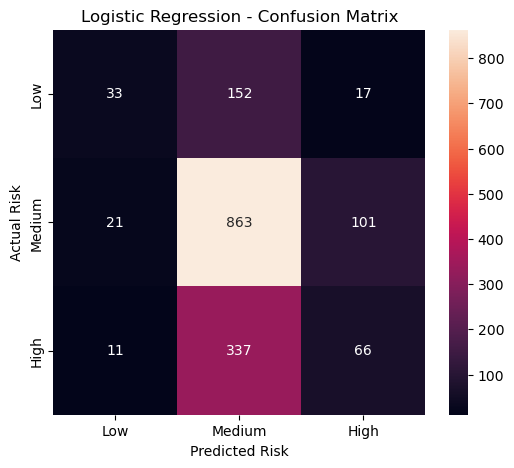

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")

plt.show()

In [72]:
results = {}

results["Logistic Regression"] = {
    "Accuracy": accuracy_logistic,
    "Precision": precision_logistic,
    "Recall": recall_logistic,
    "F1 Score": f1_logistic
}
print(results)

{'Logistic Regression': {'Accuracy': 0.6008744534665834, 'Precision': 0.54952701529, 'Recall': 0.6008744534665834, 'F1 Score': 0.5426562120305234}}


## 2. Decision Tree Classifier

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

In [75]:
decision_tree_model.fit(X_train, y_train)
print("Decision Tree training completed!")

Decision Tree training completed!


In [76]:
y_pred_tree =  decision_tree_model.predict(X_test)
print("Decision Tree prediction completed!")

Decision Tree prediction completed!


In [77]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

precision_tree = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

recall_tree = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)


f1_tree = f1_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print("Decision Tree Results")
print("**************************")
print("Accuracy:", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall:", round(recall_tree, 4))
print("F1 Score:", round(f1_tree, 4))

Decision Tree Results
**************************
Accuracy: 0.6184
Precision: 0.577
Recall: 0.6184
F1 Score: 0.5731


In [78]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.42      0.20      0.27       202
      Medium       0.66      0.87      0.75       985
        High       0.46      0.23      0.30       414

    accuracy                           0.62      1601
   macro avg       0.51      0.43      0.44      1601
weighted avg       0.58      0.62      0.57      1601



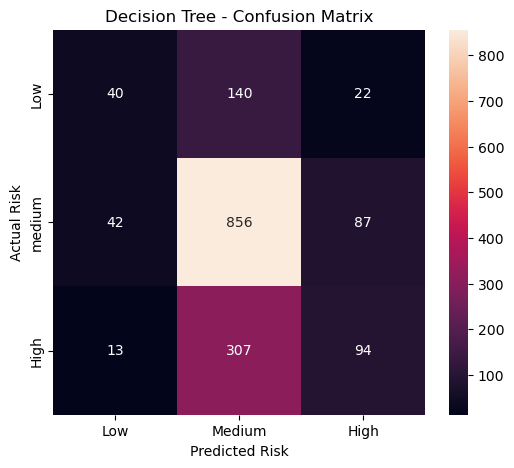

In [79]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "medium", "High"]

)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

In [80]:
results["Decision Tree"] = {
    "Accuracy": accuracy_tree,
    "Precision" : precision_tree,
    "Recall" : recall_tree,
    "F1 Score" :f1_tree
}
print(results)

{'Logistic Regression': {'Accuracy': 0.6008744534665834, 'Precision': 0.54952701529, 'Recall': 0.6008744534665834, 'F1 Score': 0.5426562120305234}, 'Decision Tree': {'Accuracy': 0.6183635227982511, 'Precision': 0.5770445926182259, 'Recall': 0.6183635227982511, 'F1 Score': 0.5731321758511004}}


## 3. Random Forest Classifier

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [83]:
random_forest_model.fit(X_train, y_train)
print("Random Forest training completed!")

Random Forest training completed!


In [84]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest prediction completed!")

Random Forest prediction completed!


In [85]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)
print("Random Fores Results")
print("**************************")
print("Acuuracy:", round(accuracy_rf,4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1 Score:", round(f1_rf, 4))

Random Fores Results
**************************
Acuuracy: 0.6271
Precision: 0.5965
Recall: 0.6271
F1 Score: 0.5654


In [86]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.55      0.13      0.21       202
      Medium       0.64      0.91      0.75       985
        High       0.50      0.21      0.29       414

    accuracy                           0.63      1601
   macro avg       0.57      0.41      0.42      1601
weighted avg       0.60      0.63      0.57      1601



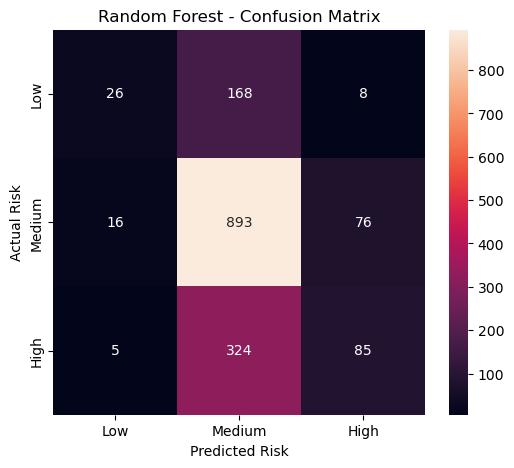

In [87]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

In [88]:
results["Random Forest"] = {
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf
}
print(results)

{'Logistic Regression': {'Accuracy': 0.6008744534665834, 'Precision': 0.54952701529, 'Recall': 0.6008744534665834, 'F1 Score': 0.5426562120305234}, 'Decision Tree': {'Accuracy': 0.6183635227982511, 'Precision': 0.5770445926182259, 'Recall': 0.6183635227982511, 'F1 Score': 0.5731321758511004}, 'Random Forest': {'Accuracy': 0.6271080574640849, 'Precision': 0.5965417837213954, 'Recall': 0.6271080574640849, 'F1 Score': 0.5653890387517626}}


## 4. Support Vector Machine

In [89]:
from sklearn.svm import SVC

In [90]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [91]:
svm_model.fit(X_train, y_train)
print("SVM training completed.!")

SVM training completed.!


In [92]:
y_pred_svm = svm_model.predict(X_test)
print("SVM prediction completed.!")

SVM prediction completed.!


In [93]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)
print("SVM Results")
print("**************************")
print("Accuracy:", round(accuracy_svm,4))
print("Precision:", round(precision_svm,4))
print("Recall:",round(recall_svm,4))
print("F1 Score:", round(f1_svm,4))

SVM Results
**************************
Accuracy: 0.6284
Precision: 0.6203
Recall: 0.6284
F1 Score: 0.5209


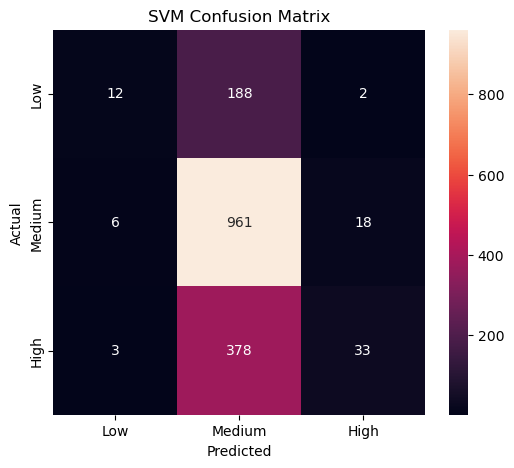

In [94]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [95]:
results["SVM"] = {
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": f1_svm
}
print(results)

{'Logistic Regression': {'Accuracy': 0.6008744534665834, 'Precision': 0.54952701529, 'Recall': 0.6008744534665834, 'F1 Score': 0.5426562120305234}, 'Decision Tree': {'Accuracy': 0.6183635227982511, 'Precision': 0.5770445926182259, 'Recall': 0.6183635227982511, 'F1 Score': 0.5731321758511004}, 'Random Forest': {'Accuracy': 0.6271080574640849, 'Precision': 0.5965417837213954, 'Recall': 0.6271080574640849, 'F1 Score': 0.5653890387517626}, 'SVM': {'Accuracy': 0.6283572767020612, 'Precision': 0.6203002186838743, 'Recall': 0.6283572767020612, 'F1 Score': 0.5208619762618436}}


## 5. K-Nearest Neighbors (KNN)

In [96]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [98]:
knn_model.fit(X_train, y_train)
print("KNN training completed.!")

KNN training completed.!


In [99]:
y_pred_knn = knn_model.predict(X_test)
print("KNN prediction completed.!")

KNN prediction completed.!


In [100]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)
f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

print("KNN Results")
print("**************************")
print("Accuracy:", round(accuracy_knn,4))
print("Precision:", round(precision_knn,4))
print("Recall:", round(recall_knn,4))
print("F1 Score:", round(f1_knn,4))

KNN Results
**************************
Accuracy: 0.5965
Precision: 0.549
Recall: 0.5965
F1 Score: 0.5529


In [101]:
results["KNN"] = {
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1 Score" : f1_knn
    

}
    
print(results)

{'Logistic Regression': {'Accuracy': 0.6008744534665834, 'Precision': 0.54952701529, 'Recall': 0.6008744534665834, 'F1 Score': 0.5426562120305234}, 'Decision Tree': {'Accuracy': 0.6183635227982511, 'Precision': 0.5770445926182259, 'Recall': 0.6183635227982511, 'F1 Score': 0.5731321758511004}, 'Random Forest': {'Accuracy': 0.6271080574640849, 'Precision': 0.5965417837213954, 'Recall': 0.6271080574640849, 'F1 Score': 0.5653890387517626}, 'SVM': {'Accuracy': 0.6283572767020612, 'Precision': 0.6203002186838743, 'Recall': 0.6283572767020612, 'F1 Score': 0.5208619762618436}, 'KNN': {'Accuracy': 0.5965021861336665, 'Precision': 0.5490415389801164, 'Recall': 0.5965021861336665, 'F1 Score': 0.5528654112222291}}


In [102]:
results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.6009,0.5495,0.6009,0.5427
Decision Tree,0.6184,0.5770,0.6184,0.5731
Random Forest,0.6271,0.5965,0.6271,0.5654
SVM,0.6284,0.6203,0.6284,0.5209
KNN,0.5965,0.5490,0.5965,0.5529


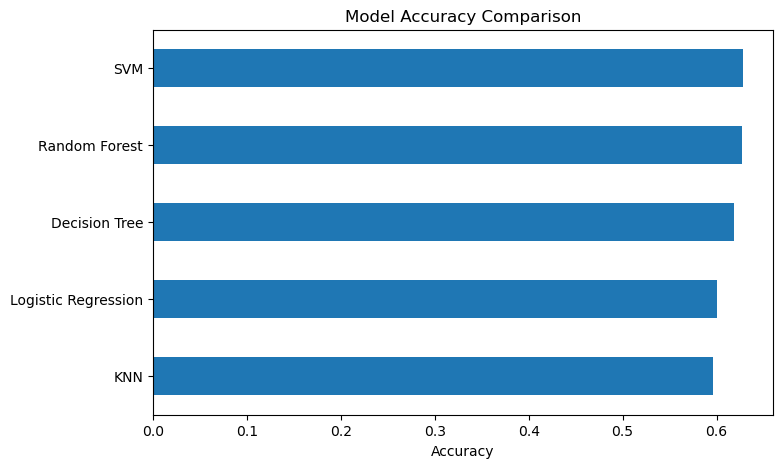

In [103]:
results_df["Accuracy"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.show()

## Hyperparameter Tuning
* GridSearchCV is used to perform hyperparameter tuning.
* It helps identify the best-performing parameter combination using cross-validation.

In [104]:
from sklearn.model_selection import GridSearchCV

In [105]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

print("Parameter grid created.")

Parameter grid created.


In [106]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [107]:
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

In [108]:
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Hyperparameter tuning completed.


In [109]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [110]:
print(
    "Best Cross_Validation F1 Score:",
    round(grid_search.best_score_, 4)
)

Best Cross_Validation F1 Score: 0.5612


## Best Random Forest Model
* The best-performing Random Forest model identified by GridSearchCV is stored in best_rf_model.
* This optimized model is then ready to be used for prediction and performance evaluation on the test dataset.

In [111]:
best_rf_model = grid_search.best_estimator_

print("Best Random Forest model loaded successfully!")
print(best_rf_model)

Best Random Forest model loaded successfully!
RandomForestClassifier(n_jobs=-1, random_state=42)


In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_best_rf = best_rf_model.predict(X_test)

accuracy_best_rf = accuracy_score(
    y_test,
    y_pred_best_rf
)

precision_best_rf = precision_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)

recall_best_rf = recall_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)

f1_best_rf = f1_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)

print("Tuned Random Forest Results")
print("**************************")
print("Accuracy:", round(accuracy_best_rf, 4))
print("Precision:", round(precision_best_rf, 4))
print("Recall:", round(recall_best_rf, 4))
print("F1 Score:", round(f1_best_rf, 4))

Tuned Random Forest Results
**************************
Accuracy: 0.6271
Precision: 0.5965
Recall: 0.6271
F1 Score: 0.5654


In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_best_rf,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.55      0.13      0.21       202
      Medium       0.64      0.91      0.75       985
        High       0.50      0.21      0.29       414

    accuracy                           0.63      1601
   macro avg       0.57      0.41      0.42      1601
weighted avg       0.60      0.63      0.57      1601



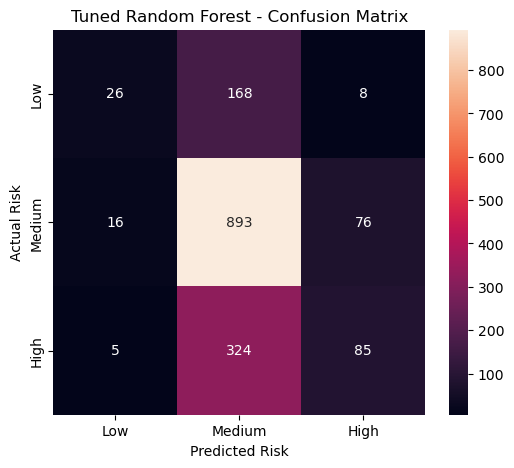

In [114]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_best_rf = confusion_matrix(
    y_test,
    y_pred_best_rf
)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

## Feature Importance Analysis
* The feature_importances_ attribute is used to measure the importance of each feature in the trained Random Forest model.
* The features are sorted in descenting order, anf the top 15 most influential features are displayed for further analysis.

In [115]:
feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
)
feature_importance = feature_importance.sort_values(
    ascending=False
)

print(feature_importance.head(15))

preci                                  0.079231
Temp                                   0.078844
day                                    0.069620
year                                   0.062531
LAI                                    0.060484
Latitude                               0.052404
Longitude                              0.052117
mon                                    0.045808
Disease_Dengue                         0.011340
Disease_Cholera                        0.009710
Disease_Chikungunya                    0.008029
Disease_Malaria                        0.007110
state_ut_West Bengal                   0.006168
week_of_outbreak_28th week             0.005709
Disease_Acute Encephalitis Syndrome    0.005681
dtype: float64


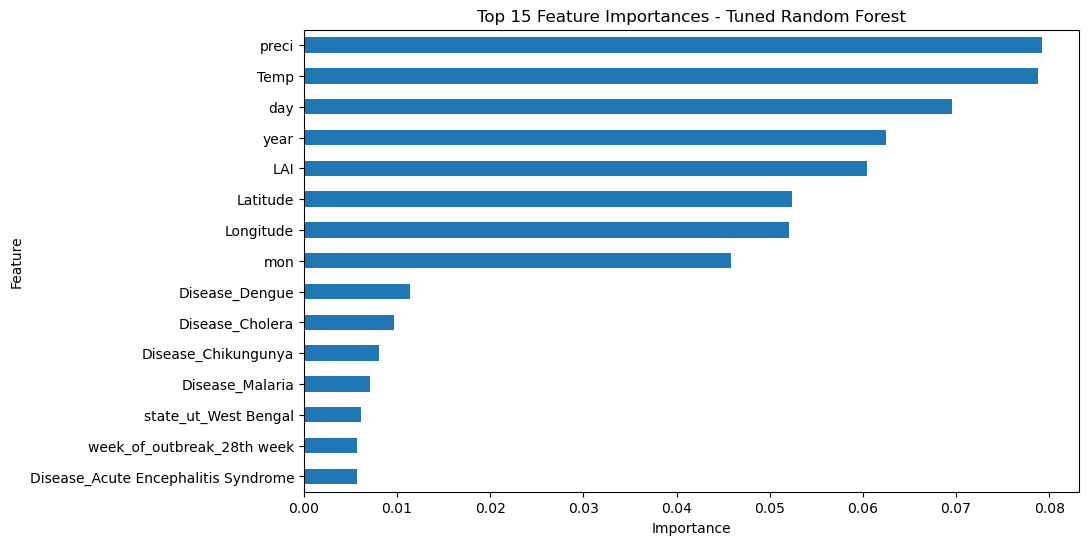

In [116]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [117]:
results["Tuned Random Forest"] = {
    "Accuracy": accuracy_best_rf,
    "Precision": precision_best_rf,
    "Recall": recall_best_rf,
    "F1 Score": f1_best_rf
}

results_df = pd.DataFrame(results).T.round(4)

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.6009,0.5495,0.6009,0.5427
Decision Tree,0.6184,0.5770,0.6184,0.5731
Random Forest,0.6271,0.5965,0.6271,0.5654
SVM,0.6284,0.6203,0.6284,0.5209
KNN,0.5965,0.5490,0.5965,0.5529
Tuned Random Forest,0.6271,0.5965,0.6271,0.5654


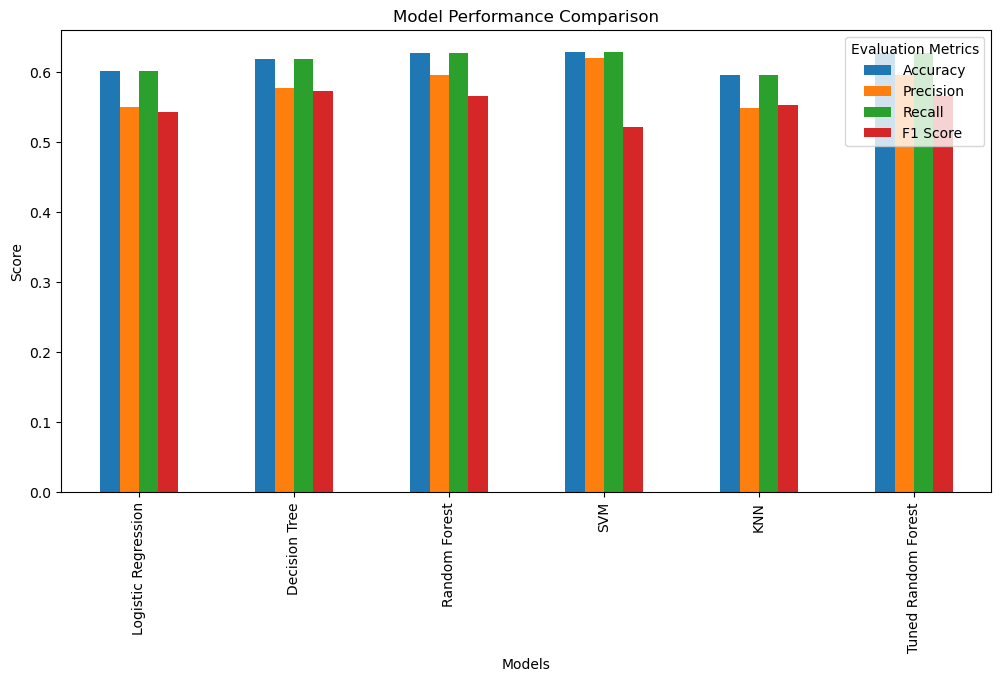

In [118]:
results_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=90)

plt.legend(
    title="Evaluation Metrics"
)
plt.show()